In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\2_comp
scenario=2comp_equal  K_MODEL=5  K_TRUE=2
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-1134.24, +1378.71]
  Alt2       [-761.20, +763.81]
  Alt3       [-366.91, +402.87]
  Price      [-516.02, +439.61]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-12.82, +17.16]
  Alt2       [-20.07, +21.99]
  Alt3       [-7.87, +12.40]
  Price      [-20.61, +10.66]



Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0303,0.0114,0.0777,0.3508
HMC,0.3020,0.2209,0.3023,0.2129
NUTS,0.3069,0.2337,0.3422,0.2189
replication,0.0390,0.0436,0.1315,0.0983
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0210  0.0047  0.0572  0.3260     0.0093  0.0067  0.0206   
HMC            0.2129  0.0267  0.2225  0.1463     0.0891  0.1942  0.0798   
NUTS           0.2378  0.0379  0.2623  0.1597     0.0691  0.1958  0.0799   
replication    0.0309  0.0038  0.1081  0.0758     0.0081  0.0398  0.0235   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.0248  
HMC          0.0665  
NUTS         0.0591  
replication  0.0224  
True DGP     0.0000

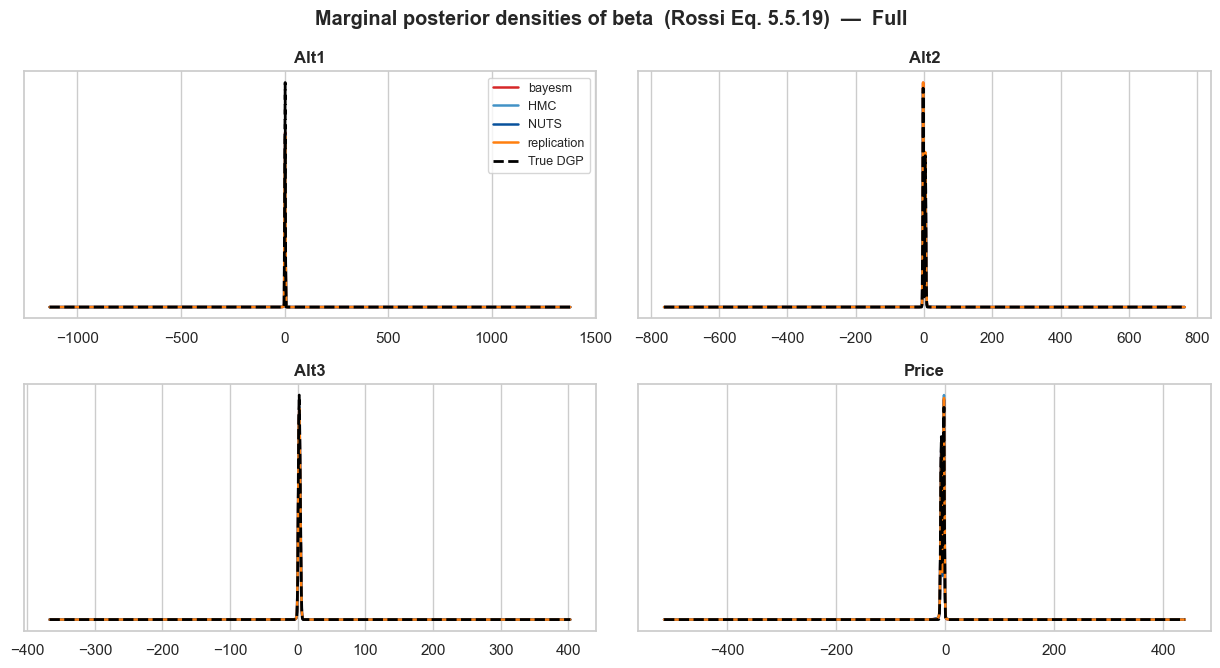

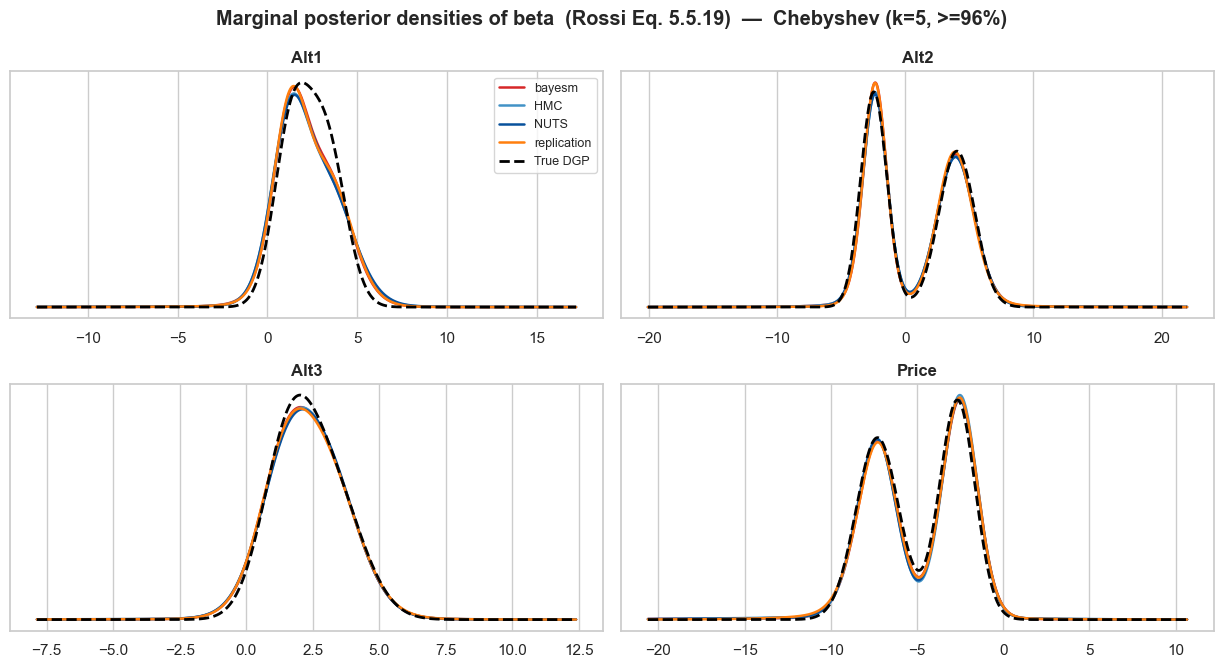

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, replication
# orange, Liesel gradient samplers in blues. Densities are cached in
# DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:316: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger   KL      JSD      TVD  Wasserstein1
sampler     param                                                
bayesm      Alt1     0.11891  inf  0.01309  0.13073       0.38503
            Alt2     0.07083  inf  0.00427  0.03785       0.13841
            Alt3     0.05727  inf  0.00277  0.02627       0.08595
            Price    0.09174  inf  0.00657  0.05012       0.25504
HMC         Alt1     0.13865  inf  0.01732  0.15010       0.54042
            Alt2     0.07998  inf  0.00512  0.03877       0.21700
            Alt3     0.07056  inf  0.00399  0.02802       0.13517
            Price    0.09935  inf  0.00770  0.05497       0.27142
NUTS        Alt1     0.13853  inf  0.01719  0.14718       0.54236
            Alt2     0.07883  inf  0.00492  0.03768       0.23605
            Alt3     0.07389  inf  0.00436  0.03016       0.14364
            Price    0.09274  inf  0.00677  0.04865       0.25289
replication Alt1     0.12488  inf  0.01444  0.13980       0.41346
            Alt2     0.06963  inf  0.00411  0.03995       0.15972
            Alt3     0.06140  inf  0.00313  0.02890       0.10128
            Price    0.08488  inf  0.00590  0.05095       0.21159

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.10849  0.11564  0.01082  0.09454       0.25622
            Alt2     0.06950  0.08211  0.00411  0.04286       0.13297
            Alt3     0.05378  0.03539  0.00250  0.02523       0.07480
            Price    0.08168  0.18910  0.00536  0.04713       0.19948
HMC         Alt1     0.12550  0.21359  0.01431  0.10887       0.30919
            Alt2     0.07244  0.16226  0.00431  0.04161       0.14922
            Alt3     0.05891  0.05055  0.00294  0.02623       0.07675
            Price    0.09389  0.25659  0.00697  0.05248       0.23530
NUTS        Alt1     0.12732  0.22598  0.01468  0.10787       0.30857
            Alt2     0.07064  0.16797  0.00405  0.03854       0.15411
            Alt3     0.06127  0.05761  0.00318  0.02883       0.07961
            Price    0.08668  0.19700  0.00601  0.04640       0.21035
replication Alt1     0.11182  0.14464  0.01145  0.09926       0.26724
            Alt2     0.06711  0.08838  0.00383  0.04364       0.14846
            Alt3     0.05580  0.04354  0.00267  0.02741       0.08122
            Price    0.08196  0.12388  0.00557  0.04918       0.19425

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.209,2.181,2.170,2.209,2.307
Alt2,0.875,0.927,0.960,0.912,0.791
Alt3,2.292,2.268,2.267,2.285,2.357
Price,-4.973,-4.935,-4.951,-4.915,-4.978


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,3.093,7.837,8.924000,3.197,1.982
Alt2,12.361,15.337,17.589001,12.576,12.009
Alt3,2.361,3.847,4.076000,2.574,1.840
Price,9.704,9.397,9.463000,8.456,6.678


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.

--- bayesm  (fit wall-clock: 217s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.017   290.273  1821.318       1.336       8.385
      sd          1.006   505.940   873.990       2.329       4.024
      q05         1.028    92.462   718.154       0.426       3.306
      q50         1.004   643.430  2242.183       2.962      10.323
      q95         1.017   231.740   786.992       1.067       3.623
Alt2  mean        1.006   496.179  3537.536       2.284      16.287
      sd          1.018   145.247   617.279       0.669       2.842
      q05         1.027    73.155   275.417       0.337       1.268
      q50         1.000  6605.754  7063.599      30.413      32.521
      q95         1.006   376.535   836.787       1.734       3.853
Alt3  mean        1.003   642.789  1732.775       2.959       7.978
      sd          1.001   898.598  1523.518       4.137       7.014
      q05         1.004   636.132  1253.388       2.929       5.771
      q50         1.005   586.534  1679.631       2.700       7.733
      q95         1.001   550.121  1081.839       2.533       4.981
Price mean        1.047    30.231    53.996       0.139       0.249
      sd          1.121    12.192    42.171       0.056       0.194
      q05         1.027    79.972   111.671       0.368       0.514
      q50         1.000  3421.020  4200.546      15.751      19.340
      q95         1.001  3064.618  6435.802      14.110      29.631

--- HMC  (fit wall-clock: 288s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.020    95.935    60.116       0.333       0.209
      sd          1.039    52.105    89.140       0.181       0.309
      q05         1.032    48.086    95.776       0.167       0.332
      q50         1.006   154.137   342.731       0.535       1.189
      q95         1.037    50.310   215.703       0.175       0.748
Alt2  mean        1.018    51.396   238.576       0.178       0.828
      sd          1.052    48.206    73.682       0.167       0.256
      q05         1.102    15.304    90.397       0.053       0.314
      q50         1.003  2025.736   599.533       7.029       2.080
      q95         1.016    63.693   148.025       0.221       0.514
Alt3  mean        1.009   101.833   274.445       0.353       0.952
      sd          1.008    96.840   146.513       0.336       0.508
      q05         1.008   245.658   572.402       0.852       1.986
      q50         1.004   115.727   357.066       0.402       1.239
      q95         1.016    93.888   345.797       0.326       1.200
Price mean        1.078    18.445    64.325       0.064       0.223
      sd          1.192     7.777    22.661       0.027       0.079
      q05         1.110    12.944    38.846       0.045       0.135
      q50         1.002  1003.478   632.341       3.482       2.194
      q95         1.008   320.130   706.370       1.111       2.451

--- NUTS  (fit wall-clock: 2,733s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.005   375.133   333.144       0.137       0.122
      sd          1.009   325.759   212.202       0.119       0.078
      q05         1.005   554.379  1703.101       0.203       0.623
      q50         1.004  1057.967  3151.428       0.387       1.153
      q95         1.003   388.458   408.830       0.142       0.150
Alt2  mean        1.013   360.167   463.961       0.132       0.170
      sd          1.009   197.397   196.662       0.072       0.072
      q05         1.014   425.795   843.809       0.156       0.309
      q50         1.001  4654.268  5313.038       1.703       1.944
      q95         1.004   610.199  1062.295       0.223       0.389
Alt3  mean        1.002   374.528   583.273       0.137       0.213
      sd          1.006   304.850   456.392       0.112       0.167
      q05         1.001   846.123  2053.279       0.310       0.751
      q50         1.000   977.413  2310.667       0.358       0.845
      q95         1.008   443.335   779.577       0.162       0.285
Price mean        1.022    93.496   303.867       0.034       0.111
      sd          1.048    44.330   217.434       0.016       0.080
      q05         1.048    43.051   104.076       0.016       0.038
      q50         1.002  2981.223  3993.101       1.091       1.461
      q95         1.000  3109.972  6820.300       1.138       2.496

--- replication  (fit wall-clock: 161s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.006   228.298   842.060       1.419       5.233
      sd          1.013   136.570   248.430       0.849       1.544
      q05         1.010   218.385   738.329       1.357       4.589
      q50         1.005   360.873   832.833       2.243       5.176
      q95         1.005   212.905   488.681       1.323       3.037
Alt2  mean        1.001   830.244  4235.178       5.160      26.322
      sd          1.010    97.157    78.649       0.604       0.489
      q05         1.029   101.178   462.235       0.629       2.873
      q50         1.000  5089.828  6197.040      31.633      38.515
      q95         1.006   147.091   128.331       0.914       0.798
Alt3  mean        1.018    97.572   349.550       0.606       2.172
      sd          1.014   113.005    93.643       0.702       0.582
      q05         1.014   579.654  1310.479       3.603       8.145
      q50         1.004   409.095  1668.719       2.543      10.371
      q95         1.007   145.573   316.134       0.905       1.965
Price mean        1.050    32.427   218.861       0.202       1.360
      sd          1.147     9.997    53.916       0.062       0.335
      q05         1.120    15.216   134.410       0.095       0.835
      q50         1.001  2923.001  4701.163      18.167      29.218
      q95         1.001  2668.580  5776.368      16.585      35.900

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
